# **K-means clustering**

**It is a simple and elegant approach for partitioning a data set into K distinct, non-overlapping clusters.**

**To perform K-means clustering, we must first specify the desired number of clusters K; then the K-means algorithm will assign each observation to exactly one of the Kclusters.**

**The K-means clustering procedure results from a simple and intuitive mathematical problem. We begin by defining some notation.**

# **Let C1,...,CK denote sets containing the indices of the observations in each cluster. These sets satisfy two properties:**
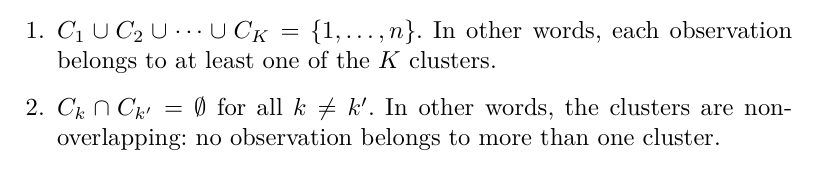
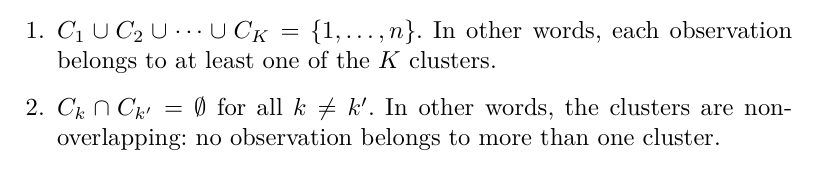

# **For instance, if the ith observation is in the kth cluster, then i belongs to Ck. The idea behind K-means clustering is that a good clustering is one for which the within-cluster variation is as small as possible. The within-cluster variation for cluster Ck is a measure W(Ck) of the amount by which the observations within a cluster differ from each other. Hence we want to solve the problem**

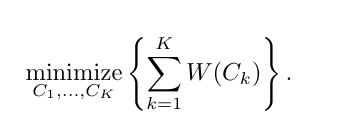

**Solving (12.15) seems like a reasonable idea, but in order to make it
actionable we need to define the within-cluster variation. There are many
possible ways to define this concept, but by far the most common choice
involves squared Euclidean distance. That is, we define**

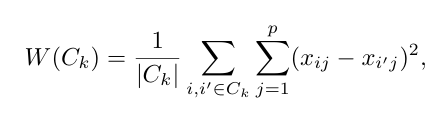

**where |Ck| denotes the number of observations in the kth cluster. In other
words, the within-cluster variation for the kth cluster is the sum of all of
the pairwise squared Euclidean distances between the observations in the
kth cluster, divided by the total number of observations in the kth cluster.**

# **So our optimization problem that defines K-Means Clustering**

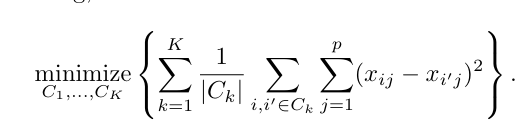

# **So our algorithm to achieve a good clustering turns to be**

**1. Randomly assign a number, from 1 to K, to each of the observations.
These serve as initial cluster assignments for the observations.**

**2. Iterate until the cluster assignments stop changing:**

    (a) For each of the K clusters, compute the cluster centroid. The
    kth cluster centroid is the vector of the p feature means for the
    observations in the kth cluster.
    (b) Assign each observation to the cluster whose centroid is closest
    (where closest is defined using Euclidean distance)

**Algorithm is guaranteed to decrease the value of the objective
at each step. To understand why, the following identity is illuminating**

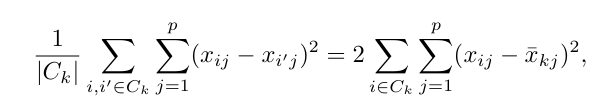

# **Now lets have a look at its practical aspect**

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Importing the Required Libraries

In [2]:
import numpy as np,pandas as pd
import matplotlib.pyplot as plt,seaborn as sns

from sklearn.cluster import KMeans

# Loading the dataset in the form of DataFrame

In [3]:
df=pd.read_csv("/kaggle/input/datasets/neurocipher/kmeans-clustering-2d-dataset/dataset.csv")

In [4]:
df.head()

,x,y
0,0.496714,4.861736
1,0.647689,6.523030
2,-0.234153,4.765863
3,1.579213,5.767435
4,-0.469474,5.542560


# Applying KMeans Clustering with different values of k (by sklearn)

In [5]:
X=df[["x", "y"]].values

In [6]:
k_values=[3,4,5]

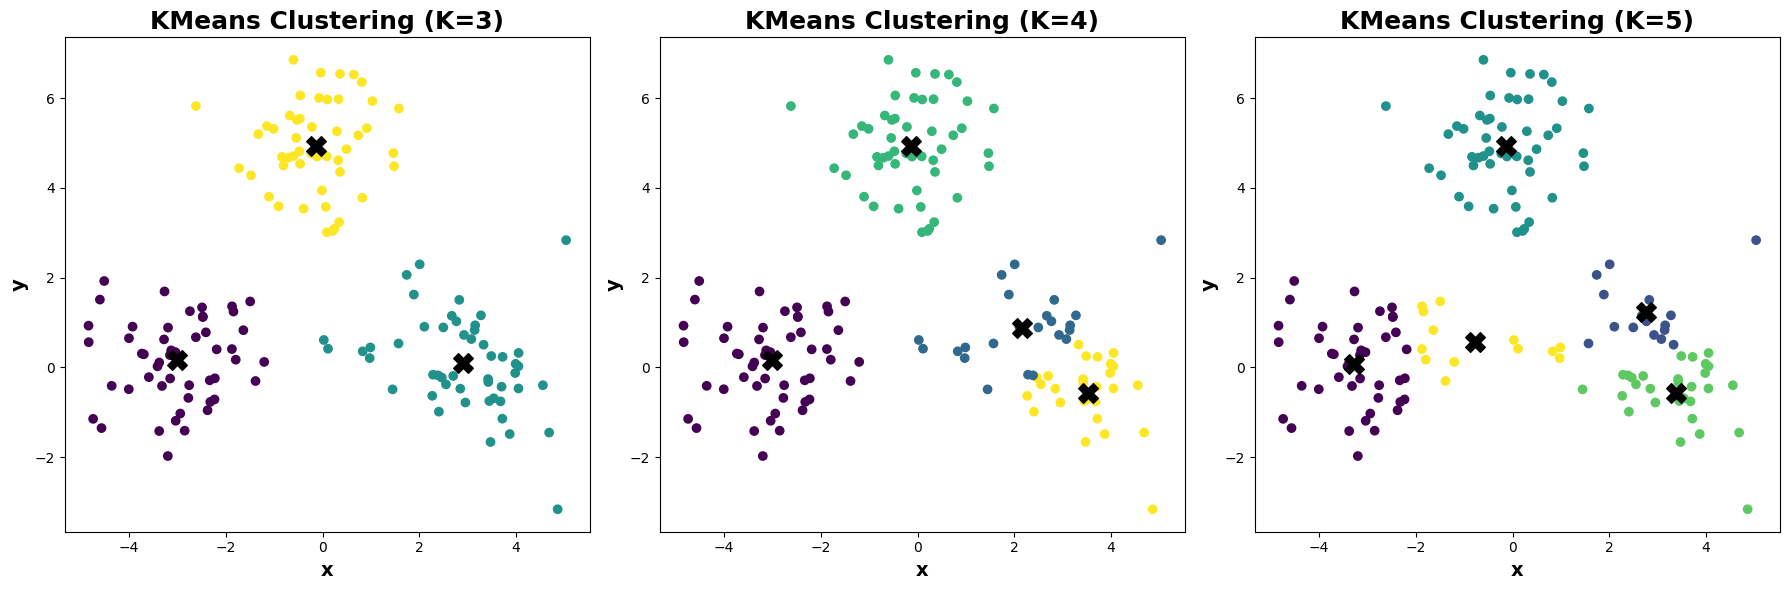

In [7]:
fig,axes=plt.subplots(1,3,figsize=(18,6))

for idx,k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)

    labels = kmeans.labels_
    centroids = kmeans.cluster_centers_

    
    axes[idx].scatter(X[:,0], X[:,1], c=labels)
    axes[idx].scatter(centroids[:,0],centroids[:,1],marker='X',s=200,c='black')
    
    axes[idx].set_title(f"KMeans Clustering (K={k})",fontweight='bold',fontsize=18)
    axes[idx].set_xlabel("x",fontweight='bold',fontsize=14)
    axes[idx].set_ylabel("y",fontweight='bold',fontsize=14)
    
plt.tight_layout()
plt.show()

# Analyzing the KMeans clustering with k=3 in depth

In [8]:
np.random.seed(42)
K = 3

In [9]:
# Initializing the centroids randomly
random_indices = np.random.choice(len(X), K, replace=False)
centroids = X[random_indices]

In [10]:
def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, K):
    return np.array([X[labels == k].mean(axis=0) for k in range(K)])

In [11]:
history = []
labels = None

In [12]:
while True:
    new_labels = assign_clusters(X, centroids)
    
    # Save current state
    history.append((centroids.copy(), new_labels.copy()))
    
    # Stop if assignments do not change
    if labels is not None and np.array_equal(new_labels, labels):
        break
    
    labels = new_labels
    centroids = update_centroids(X, labels, K)

print(f"Converged in {len(history)} iterations.")

Converged in 5 iterations.


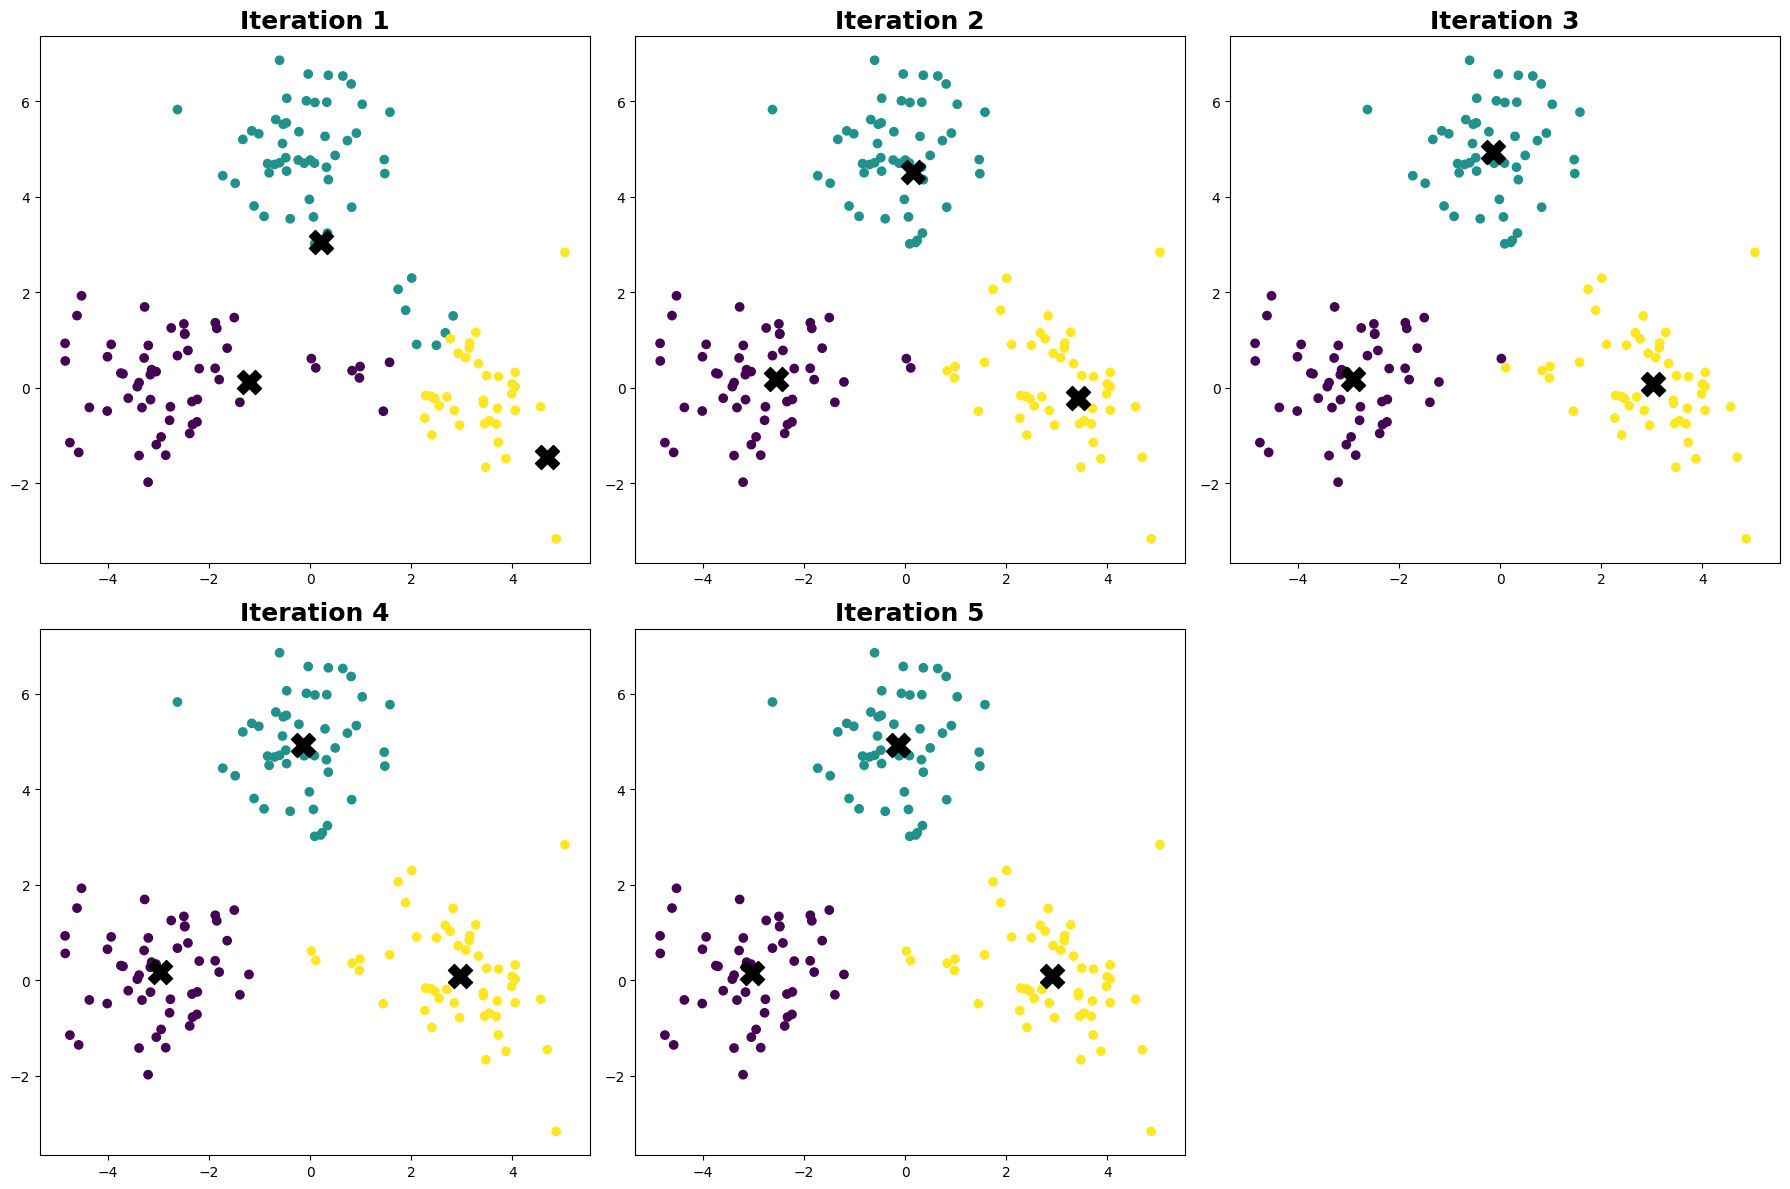

In [13]:
cols = 3
rows = int(np.ceil(len(history) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(18, 6*rows))
axes = axes.flatten()

for i, (centroids, labels) in enumerate(history):
    axes[i].scatter(X[:,0], X[:,1], c=labels)
    axes[i].scatter(centroids[:,0], centroids[:,1],marker='X', s=300, c='black')
    axes[i].set_title(f"Iteration {i+1}",fontweight='bold',fontsize=18)

# Hide unused plots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# **Thanks for your attention!**